In [7]:
import pandas as pd, numpy as np 
import matplotlib.pyplot as plt, seaborn as sns
import warnings 
warnings.filterwarnings("ignore")


In [8]:
df = pd.read_csv("Country-data.csv") 
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [10]:
df.shape

(167, 10)

In [11]:
df["exports"] = df["exports"]*df["gdpp"]/100
df["imports"] = df["imports"]*df["gdpp"]/100
df["health"] = df["health"]*df["gdpp"]/100


In [12]:
### missing value check 


In [13]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [14]:
#Dropping the country column 
df1 = df.drop("country", axis = 1) 
df1.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


In [15]:
## scalling Mandantory 

In [16]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler()
df1_scaled = scaler.fit_transform(df1)


In [18]:
df1_scaled

array([[4.26484907e-01, 2.95093321e-04, 3.36341972e-03, ...,
        4.75345168e-01, 7.36593060e-01, 3.07342821e-03],
       [6.81596884e-02, 6.22655666e-03, 2.94856458e-02, ...,
        8.71794872e-01, 7.88643533e-02, 3.68334145e-02],
       [1.20253165e-01, 9.31468360e-03, 2.00167874e-02, ...,
        8.75739645e-01, 2.74447950e-01, 4.03649935e-02],
       ...,
       [1.00778968e-01, 5.12723048e-03, 8.87582515e-03, ...,
        8.08678501e-01, 1.26182965e-01, 1.02988479e-02],
       [2.61441091e-01, 2.13292722e-03, 6.36206303e-03, ...,
        6.98224852e-01, 5.55205047e-01, 1.02988479e-02],
       [3.91918208e-01, 2.93402035e-03, 8.45852168e-03, ...,
        3.92504931e-01, 6.70347003e-01, 1.17305692e-02]])

In [23]:
from sklearn.cluster import KMeans


In [25]:
ls = []
for k in range(2, 20): 
    kMeans = KMeans(n_clusters = k)
    kMeans.fit(df1_scaled)
    ls.append([k,kMeans.inertia_])
    

In [27]:
er = pd.DataFrame(ls,columns=["No. of clusters","Error"]) 
er


,No. of clusters,Error
0,2,24.291111
1,3,13.735100
2,4,11.601848
3,5,9.816865
4,6,8.324579
5,7,7.388087
6,8,6.833266
7,9,6.021303
8,10,5.235721
9,11,4.935812


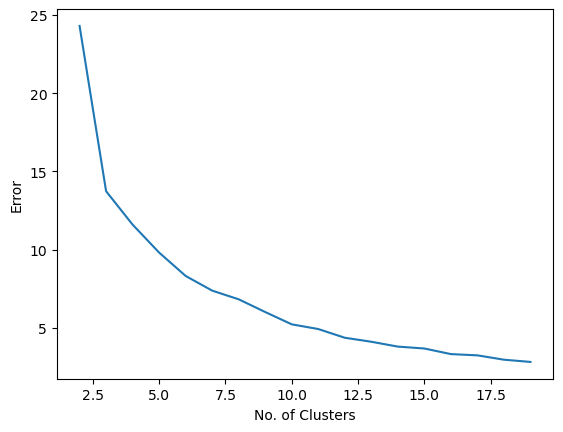

In [28]:
plt.plot(er["No. of clusters"],er["Error"]) 
plt.xlabel("No. of Clusters") 
plt.ylabel("Error") 
plt.show()
